In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# install xlrd
!pip install xlrd

print('xlrd installed!')

xlrd installed!


In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/VNindex_price_datafull.csv')
print(df)

Mounted at /content/drive
            date  price_open  price_close     high      low      vol  change
0     17/02/2021     1127.46      1155.78  1155.78  1127.46  568.03K   3.66%
1     09/02/2021     1090.88      1114.93  1114.93  1078.98  519.81K   2.93%
2     08/02/2021     1127.06      1083.18  1127.06  1075.10  696.60K  -3.88%
3     05/02/2021     1114.79      1126.91  1126.91  1112.19  529.87K   1.32%
4     04/02/2021     1112.97      1112.19  1117.88  1098.85  523.41K   0.08%
...          ...         ...          ...      ...      ...      ...     ...
4903  12/01/2001      225.67       225.67   225.67   225.67    0.22K   1.58%
4904  10/01/2001      222.15       222.15   222.15   222.15    0.18K   1.85%
4905  08/01/2001      218.12       218.12   218.12   218.12    0.07K   1.77%
4906  05/01/2001      214.32       214.32   214.32   214.32    0.05K   1.79%
4907  03/01/2001      210.56       210.56   210.56   210.56    0.04K   1.80%

[4908 rows x 7 columns]


In [4]:
# Chuyển cột date sang dạng datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Sắp xếp dữ liệu theo thời gian
df = df.sort_values(by='date', ascending=True)

# Tạo thêm cột year để phân tích theo năm
df['year'] = df['date'].dt.year

df

,date,price_open,price_close,high,low,vol,change,year
4907,2001-01-03,210.56,210.56,210.56,210.56,0.04K,1.80%,2001
4906,2001-01-05,214.32,214.32,214.32,214.32,0.05K,1.79%,2001
4905,2001-01-08,218.12,218.12,218.12,218.12,0.07K,1.77%,2001
4904,2001-01-10,222.15,222.15,222.15,222.15,0.18K,1.85%,2001
4903,2001-01-12,225.67,225.67,225.67,225.67,0.22K,1.58%,2001
...,...,...,...,...,...,...,...,...
4,2021-02-04,1112.97,1112.19,1117.88,1098.85,523.41K,0.08%,2021
3,2021-02-05,1114.79,1126.91,1126.91,1112.19,529.87K,1.32%,2021
2,2021-02-08,1127.06,1083.18,1127.06,1075.10,696.60K,-3.88%,2021
1,2021-02-09,1090.88,1114.93,1114.93,1078.98,519.81K,2.93%,2021


**line chart:**
Biểu đồ đường được sử dụng để thể hiện xu hướng biến động của chỉ số VN-Index theo thời gian trong giai đoạn 2001–2021. Thông qua biểu đồ này, để quan sát được sự thay đổi của thị trường chứng khoán Việt Nam qua các năm, bao gồm các giai đoạn tăng trưởng mạnh, suy giảm hoặc ổn định.

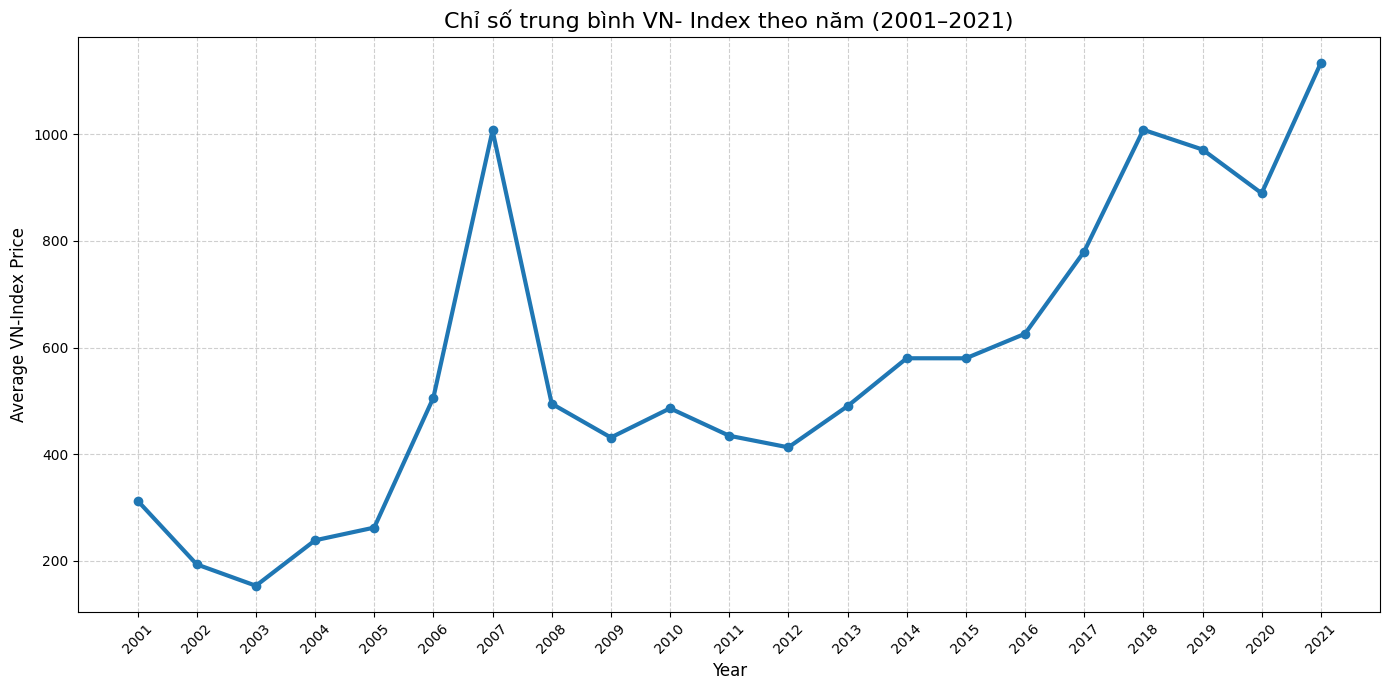

In [5]:
# Tạo cột năm
df['year'] = df['date'].dt.year

# Lấy giá trung bình theo năm
price_by_year = df.groupby('year')['price_close'].mean()

plt.figure(figsize=(14,7))

plt.plot(
    price_by_year.index,
    price_by_year.values,
    linewidth=3,
    marker='o'
)

plt.title("Chỉ số trung bình VN- Index theo năm (2001–2021)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average VN-Index Price", fontsize=12)

plt.xticks(price_by_year.index, rotation=45)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

histogram: phân tích phân bố giá VN-Index, xem mức giá nào xuất hiện nhiều nhất, đánh giá mức độ biến động của thị trường.

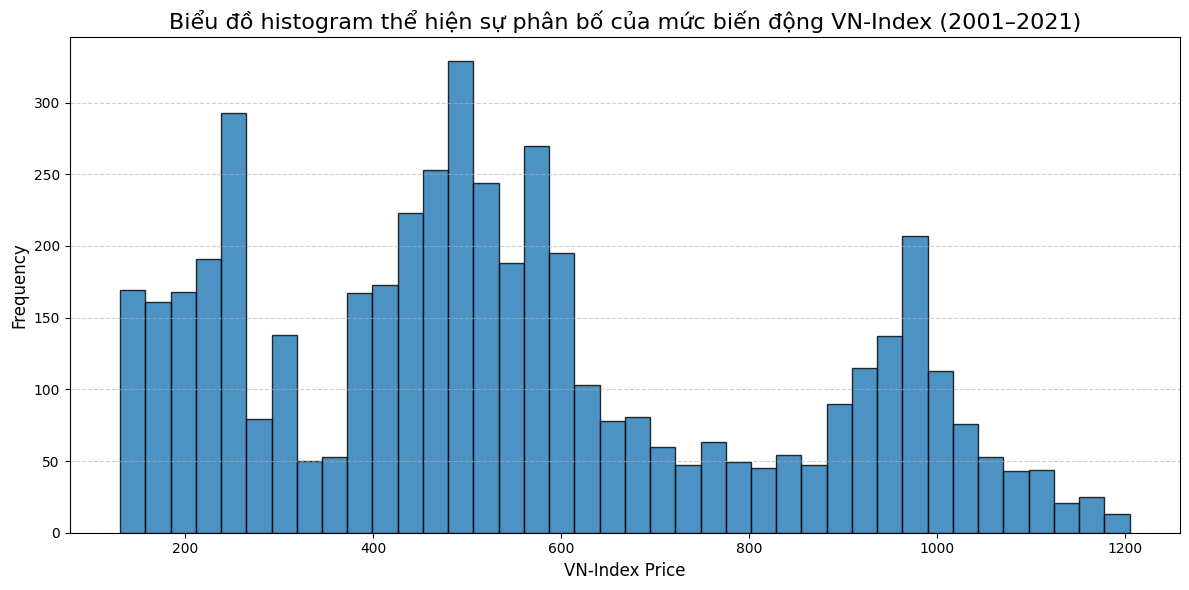

In [6]:
plt.figure(figsize=(12,6))

plt.hist(df['price_close'], bins=40, edgecolor="black", alpha=0.8)

plt.title("Biểu đồ histogram thể hiện sự phân bố của mức biến động VN-Index (2001–2021)", fontsize=16)
plt.xlabel("VN-Index Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y', linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

bar chart:
Biểu đồ cột giúp

so sánh khối lượng giao dịch giữa các năm,
xác định năm thị trường hoạt động sôi động nhất,
đánh giá mức độ quan tâm của nhà đầu tư theo từng giai đoạn

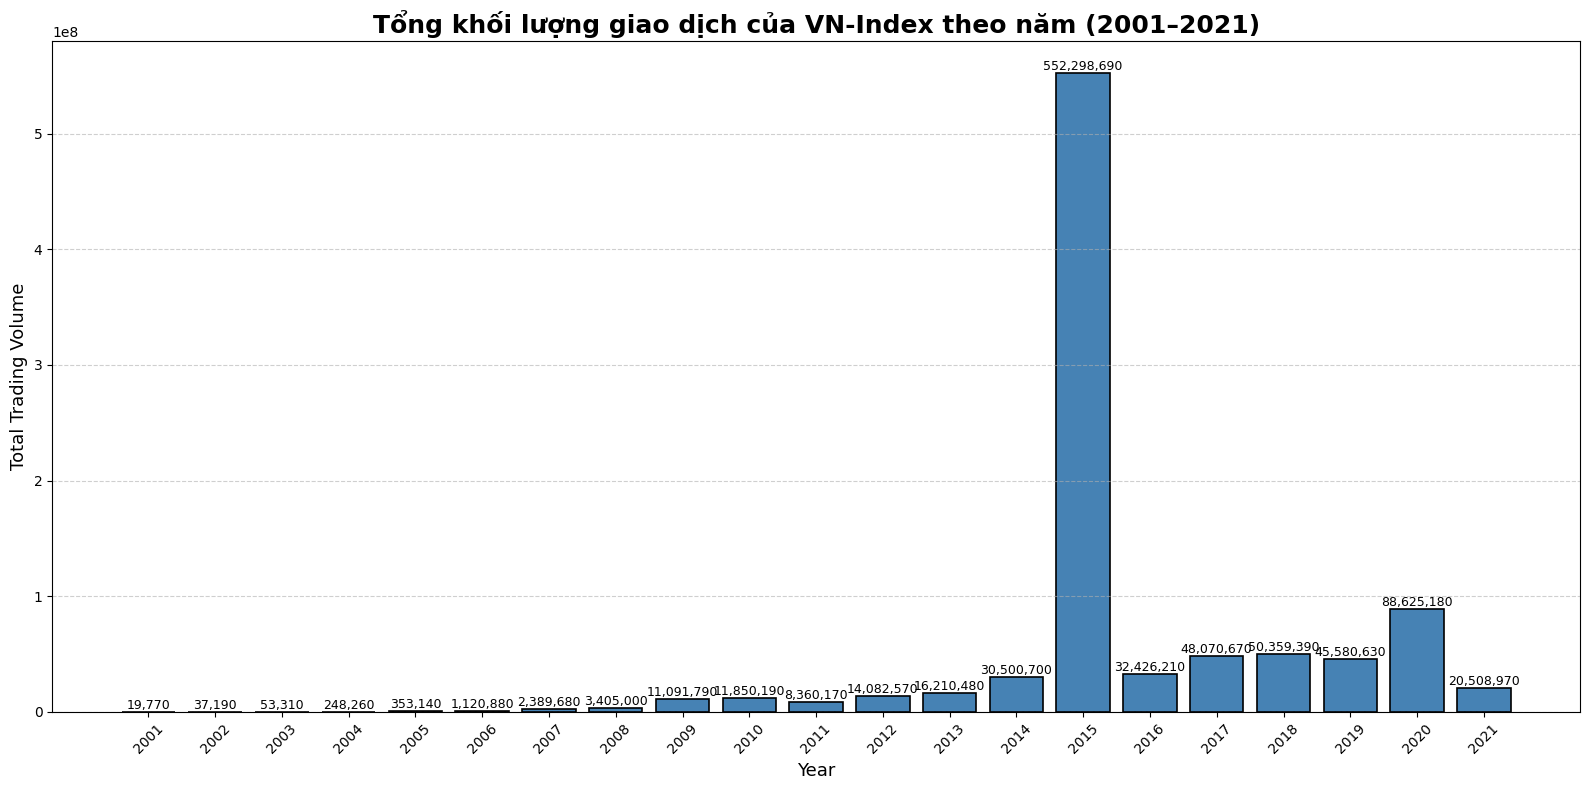

In [7]:
def clean_volume(vol_str):
    vol_str = str(vol_str).strip()
    if vol_str == '-': # Handle '-' specifically, interpret as 0 volume
        return 0.0
    if 'K' in vol_str:
        return float(vol_str.replace('K', '')) * 1000
    elif 'M' in vol_str:
        return float(vol_str.replace('M', '')) * 1000000
    return float(vol_str)

df['vol'] = df['vol'].apply(clean_volume)

# tổng volume theo năm
volume_by_year = df.groupby('year')['vol'].sum()

# vẽ biểu đồ
plt.figure(figsize=(16,8))

bars = plt.bar(
    volume_by_year.index,
    volume_by_year.values,
    color='steelblue',
    edgecolor='black',
    linewidth=1.2
)

# tiêu đề
plt.title("Tổng khối lượng giao dịch của VN-Index theo năm (2001–2021)", fontsize=18, fontweight='bold')

# nhãn trục
plt.xlabel("Year", fontsize=13)
plt.ylabel("Total Trading Volume", fontsize=13)

# hiển thị tất cả năm
plt.xticks(volume_by_year.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# hiển thị giá trị trên đầu cột
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

scatter plot giúp:

phân tích mối quan hệ giữa khối lượng giao dịch và giá thị trường,
xem khi volume tăng thì giá có tăng theo hay không,
hỗ trợ đánh giá tâm lý nhà đầu tư

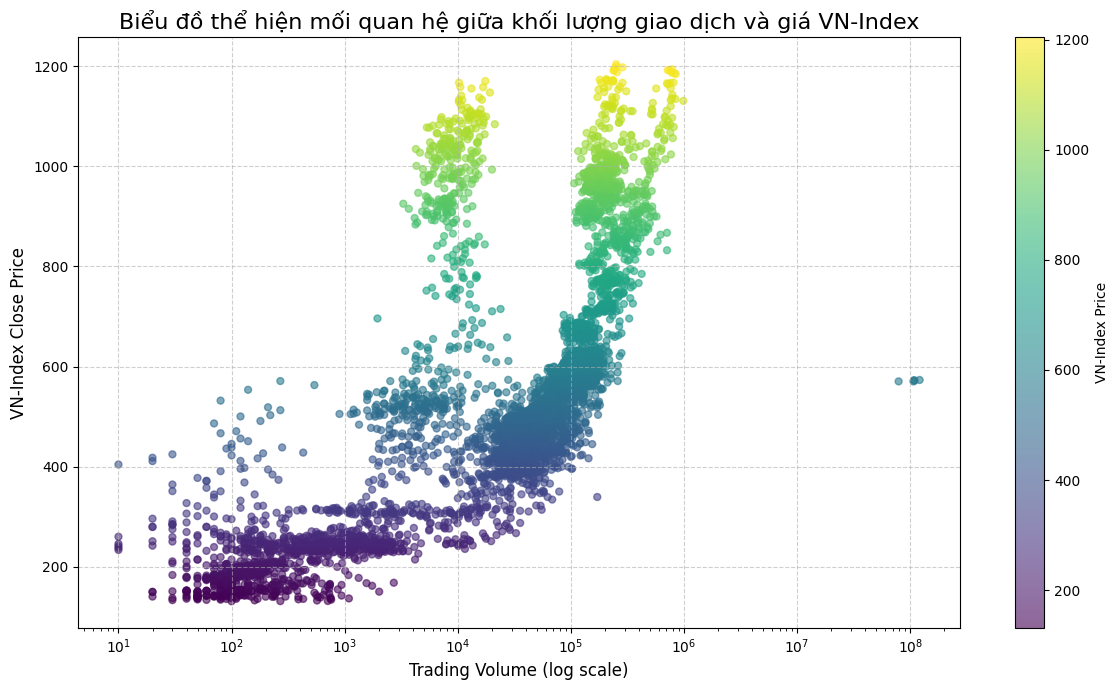

In [8]:
plt.figure(figsize=(12,7))

scatter = plt.scatter(
    df['vol'],
    df['price_close'],
    c=df['price_close'],
    alpha=0.6,
    s=25
)
# dùng log scale vì volume rất lớn
plt.xscale('log')

plt.title("Biểu đồ thể hiện mối quan hệ giữa khối lượng giao dịch và giá VN-Index", fontsize=16)
plt.xlabel("Trading Volume (log scale)", fontsize=12)
plt.ylabel("VN-Index Close Price", fontsize=12)

plt.colorbar(scatter, label="VN-Index Price")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()